# Compréhension globale du projet
## 🎯 Objectif final
```
Créer un dataset d'images propre et homogène pour entraîner un modèle de reconnaissance de déchets (6 classes : cardboard, plastic, paper, glass, metal, trash).

📚 Les 14 parties de l'atelier
Partie	Sujet
0	Structure du projet
1	Exploration du dataset
2	Détection des images corrompues
3	Détection des images vides
4	Détection des différences de résolution
5	Détection des différents canaux
6	Détection des doublons
7	Détection des images mal classées
8	Analyse du déséquilibre des classes
9	Redimensionnement
10	Uniformisation des canaux
11	Mise à l'échelle des pixels
12	Découpage Train/Validation/Test
13	Data Augmentation
14	Bonus
```

# Partie 1 – Exploration du dataset
## 🎯 Objectif
```
Lire toutes les images de chaque dossier et récupérer leurs informations :

Nom, classe, format, mode

Largeur, hauteur

Écart-type des pixels (pour détecter les images vides)

Nombre de canaux

Taille du fichier
```

## 📝 Explication imagée
# C'est comme faire l'inventaire d'un entrepôt :
```
On ouvre chaque carton (dossier)

On note ce qu'il contient (nom, taille, dimensions)

On repère les cartons abîmés (images corrompues)
```

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image, ImageStat
import warnings
warnings.filterwarnings('ignore')

# Chemins
BASE_DIR = '../data/raw'
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("✅ Bibliothèques importées")
print(f"📁 Dossier de base : {BASE_DIR}")
print(f"📂 Classes : {CLASSES}")

✅ Bibliothèques importées
📁 Dossier de base : ../data/raw
📂 Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


##  Fonction de détection d'image corrompue

In [4]:
def explorer_dataset(base_dir, classes):
    """Parcourt toutes les images et collecte leurs informations."""
    donnees = []
    
    for classe in classes:
        dossier = os.path.join(base_dir, classe)
        if not os.path.exists(dossier):
            print(f"⚠️ Dossier manquant : {dossier}")
            continue
        
        fichiers = os.listdir(dossier)
        print(f"📂 {classe} : {len(fichiers)} fichiers")
        
        for fichier in fichiers:
            chemin = os.path.join(dossier, fichier)
            
            # Ignorer les sous-dossiers
            if not os.path.isfile(chemin):
                continue
            
            # Informations de base
            info = {
                'nom': fichier,
                'classe': classe,
                'chemin': chemin,
                'taille_ko': round(os.path.getsize(chemin) / 1024, 2),
                'corrompue': False,
                'format': None,
                'mode': None,
                'largeur': None,
                'hauteur': None,
                'canaux': None,
                'ecart_type': None
            }
            
            # Vérifier si corrompue
            if est_corrompue(chemin):
                info['corrompue'] = True
                donnees.append(info)
                continue
            
            # Extraire les métadonnées
            try:
                with Image.open(chemin) as img:
                    info['format'] = img.format
                    info['mode'] = img.mode
                    info['largeur'], info['hauteur'] = img.size
                    info['canaux'] = len(img.getbands())
                    
                    # Écart-type des pixels (pour détecter images vides)
                    stat = ImageStat.Stat(img.convert('L'))
                    info['ecart_type'] = round(stat.stddev[0], 2)
            except Exception as e:
                info['corrompue'] = True
            
            donnees.append(info)
    
    return pd.DataFrame(donnees)

# Exécution
df = explorer_dataset(BASE_DIR, CLASSES)

print(f"\n✅ Exploration terminée : {len(df)} images analysées")
print(f"📊 Aperçu :")
df.head()

📂 cardboard : 169 fichiers
📂 glass : 188 fichiers
📂 metal : 149 fichiers
📂 paper : 252 fichiers
📂 plastic : 224 fichiers
📂 trash : 50 fichiers

✅ Exploration terminée : 1032 images analysées
📊 Aperçu :


,nom,classe,chemin,taille_ko,corrompue,format,mode,largeur,hauteur,canaux,ecart_type
0,cardboard1.jpg,cardboard,../data/raw\cardboard\cardboard1.jpg,16.93,False,JPEG,RGB,512.0,384.0,3.0,31.88
1,cardboard10.jpg,cardboard,../data/raw\cardboard\cardboard10.jpg,21.17,False,JPEG,RGB,512.0,384.0,3.0,38.80
2,cardboard100.jpg,cardboard,../data/raw\cardboard\cardboard100.jpg,14.54,False,JPEG,RGB,512.0,384.0,3.0,44.50
3,cardboard101.jpg,cardboard,../data/raw\cardboard\cardboard101.jpg,13.95,False,JPEG,RGB,512.0,384.0,3.0,68.56
4,cardboard102.jpg,cardboard,../data/raw\cardboard\cardboard102.jpg,17.59,False,JPEG,RGB,512.0,384.0,3.0,45.32


### Sauvegarde de l'audit

In [5]:
# Créer le dossier reports s'il n'existe pas
os.makedirs('../reports', exist_ok=True)

# Sauvegarder l'audit
df.to_csv('../reports/audit_images.csv', index=False)

print("✅ Audit sauvegardé dans '../reports/audit_images.csv'")
print(f"📊 Nombre total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

✅ Audit sauvegardé dans '../reports/audit_images.csv'
📊 Nombre total d'images : 1032
❌ Images corrompues : 6


### Statistiques générales

In [6]:
print("=== STATISTIQUES GÉNÉRALES ===\n")

print(f"📊 Total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

print("\n📂 Répartition par classe :")
print(df['classe'].value_counts())

print("\n🎨 Répartition par mode :")
print(df['mode'].value_counts())

print("\n📐 Répartition par nombre de canaux :")
print(df['canaux'].value_counts())

=== STATISTIQUES GÉNÉRALES ===

📊 Total d'images : 1032
❌ Images corrompues : 6

📂 Répartition par classe :
classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

🎨 Répartition par mode :
mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64

📐 Répartition par nombre de canaux :
canaux
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64


### ✅ Vérification

In [7]:
print("=== VÉRIFICATION PARTIE 1 ===")
print(f"✅ DataFrame créé : {df.shape}")
print(f"✅ Colonnes : {list(df.columns)}")
print(f"✅ Fichier CSV sauvegardé : ../reports/audit_images.csv")

=== VÉRIFICATION PARTIE 1 ===
✅ DataFrame créé : (1032, 11)
✅ Colonnes : ['nom', 'classe', 'chemin', 'taille_ko', 'corrompue', 'format', 'mode', 'largeur', 'hauteur', 'canaux', 'ecart_type']
✅ Fichier CSV sauvegardé : ../reports/audit_images.csv


# Partie 2 – Détection des images corrompues
## 🎯 Objectif
### Isoler toutes les images qui ne peuvent pas être lues correctement par Python, pour les exclure du dataset.

**📝 Explication imagée**
C'est comme un contrôle qualité à l'entrée d'une usine :

* On ouvre chaque colis (image)

* Si le colis est abîmé (fichier corrompu), on le met de côté

* Les bons colis continuent leur chemin

* Une image corrompue = un fichier qu'on ne peut pas ouvrir ou lire correctement (fichier tronqué, mauvais format, erreur de téléchargement...).

  ### 1 – Récapitulatif des images corrompues

In [8]:
print("=== IMAGES CORROMPUES ===\n")

# Filtrer les images corrompues
images_corrompues = df[df['corrompue'] == True]

print(f"❌ Nombre d'images corrompues : {len(images_corrompues)}")
print(f"📊 Pourcentage : {len(images_corrompues)/len(df)*100:.2f}%\n")

if len(images_corrompues) > 0:
    print("Liste des images corrompues :")
    print(images_corrompues[['nom', 'classe', 'taille_ko']].to_string(index=False))
else:
    print("✅ Aucune image corrompue détectée !")

=== IMAGES CORROMPUES ===

❌ Nombre d'images corrompues : 6
📊 Pourcentage : 0.58%

Liste des images corrompues :
            nom    classe  taille_ko
cardboard83.jpg cardboard      20.40
    glass74.jpg     glass       7.02
    metal48.jpg     metal       7.09
   paper213.jpg     paper       7.12
  plastic13.jpg   plastic       5.13
     trash3.jpg     trash       8.98


### 2 – Répartition par classe

In [9]:
if len(images_corrompues) > 0:
    print("=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===\n")
    
    repartition = images_corrompues.groupby('classe').size()
    
    for classe, nombre in repartition.items():
        total_classe = len(df[df['classe'] == classe])
        pourcentage = nombre / total_classe * 100
        print(f"📂 {classe:12s} : {nombre:3d} corrompues / {total_classe:4d} total ({pourcentage:.1f}%)")

=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===

📂 cardboard    :   1 corrompues /  169 total (0.6%)
📂 glass        :   1 corrompues /  188 total (0.5%)
📂 metal        :   1 corrompues /  149 total (0.7%)
📂 paper        :   1 corrompues /  252 total (0.4%)
📂 plastic      :   1 corrompues /  224 total (0.4%)
📂 trash        :   1 corrompues /   50 total (2.0%)


### 3 – Création du dataset propre (sans corrompues)

In [10]:
# Dataset sans les images corrompues
df_propre = df[df['corrompue'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===\n")
print(f"📊 Avant : {len(df)} images")
print(f"📊 Après : {len(df_propre)} images")
print(f"🗑️  Supprimées : {len(df) - len(df_propre)} images")
print(f"✅ Pourcentage conservé : {len(df_propre)/len(df)*100:.2f}%")

# Sauvegarder cette version
df_propre.to_csv('../reports/audit_images_sans_corrompues.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===

📊 Avant : 1032 images
📊 Après : 1026 images
🗑️  Supprimées : 6 images
✅ Pourcentage conservé : 99.42%

💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'


### 4 – Visualisation 

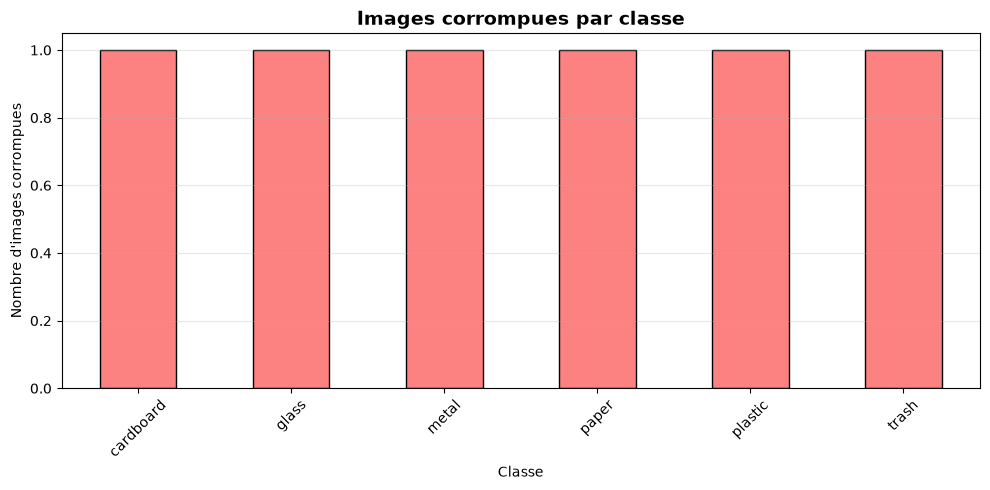

💾 Graphique sauvegardé dans '../reports/images_corrompues.png'


In [11]:
import matplotlib.pyplot as plt

if len(images_corrompues) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    repartition = images_corrompues.groupby('classe').size()
    repartition.plot(kind='bar', color='#fc8181', edgecolor='black', ax=ax)
    
    ax.set_title('Images corrompues par classe', fontsize=14, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Nombre d\'images corrompues')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/images_corrompues.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("💾 Graphique sauvegardé dans '../reports/images_corrompues.png'")

```
Dataset original (100%)
        │
        ▼
┌───────────────────────┐
│  Images corrompues ?  │
└───────────────────────┘
        │
    ┌───┴───┐
    │       │
   OUI     NON
    │       │
    ▼       ▼
  🗑️      ✅
Supprimer  Conserver
            │
            ▼
    Dataset propre
```

### ✅ Vérification

In [12]:
print("=== VÉRIFICATION PARTIE 2 ===")
print(f"✅ Fonction de détection : est_corrompue()")
print(f"✅ Images corrompues identifiées : {len(images_corrompues)}")
print(f"✅ Dataset propre : {len(df_propre)} images conservées")
print(f"✅ Fichier sauvegardé : audit_images_sans_corrompues.csv")

=== VÉRIFICATION PARTIE 2 ===
✅ Fonction de détection : est_corrompue()
✅ Images corrompues identifiées : 6
✅ Dataset propre : 1026 images conservées
✅ Fichier sauvegardé : audit_images_sans_corrompues.csv
